# EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
fake = pd.read_csv("/content/Fake.csv", engine='python', on_bad_lines='skip')
real = pd.read_csv("/content/True.csv", engine='python', on_bad_lines='skip')

In [ ]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
fake["label"] = 0
real["label"] = 1

df = pd.concat([fake, real], ignore_index=True)

print("Dataset shape:", df.shape)

print(df.columns)

Dataset shape: (44898, 5)
Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [ ]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [ ]:
df["label"].value_counts()

,count
label,
0,23481
1,21417


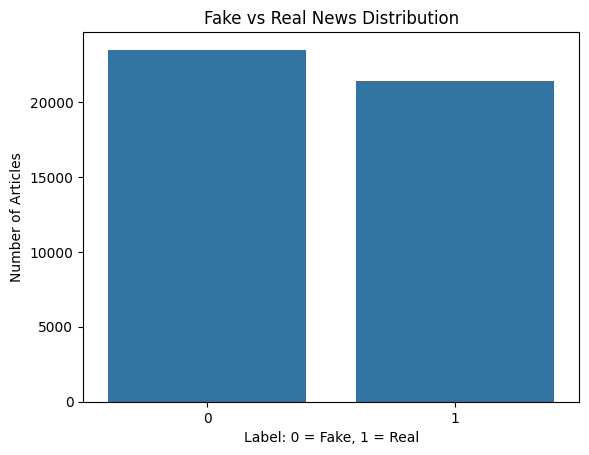

In [ ]:
sns.countplot(x=df["label"])
plt.title("Fake vs Real News Distribution")
plt.xlabel("Label: 0 = Fake, 1 = Real")
plt.ylabel("Number of Articles")
plt.show()

In [ ]:
df["full_text"] = df["title"] + " " + df["text"]
df["text_length"] = df["full_text"].apply(len)

In [ ]:
df["text_length"].describe()

,text_length
count,44898.000000
mean,2550.221413
std,2172.578772
min,31.000000
25%,1318.000000
50%,2270.000000
75%,3189.000000
max,51893.000000


In [ ]:
df.groupby("label")["text_length"].mean()

,text_length
label,
0,2642.594268
1,2448.946398


In [ ]:
fake_example = df[df["label"] == 0].iloc[0]
print("TITLE:")
print(fake_example["title"])
print("\nTEXT:")
print(fake_example["text"][:1000])

TITLE:
 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing

TEXT:
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America!  Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeti

In [ ]:
real_example = df[df["label"] == 1].iloc[0]
print("TITLE:")
print(real_example["title"])
print("\nTEXT:")
print(real_example["text"][:1000])

TITLE:
As U.S. budget fight looms, Republicans flip their fiscal script

TEXT:
WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they return from the holidays on Wednesday, lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues, such as immigration policy, even as the November congressional election campaigns approach in which Republicans will seek to keep control of Congress. President Donald Trump and his Republicans want a big budget increase in military spending, while Democrats also want proportional incr

In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df.head()

,title,text,subject,date,label,full_text,text_length
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,Ben Stein Calls Out 9th Circuit Court: Committ...,1118
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,Trump drops Steve Bannon from National Securit...,4876
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,Puerto Rico expects U.S. to lift Jones Act shi...,1913
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,OOPS: Trump Just Accidentally Confirmed He Le...,1334
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,Donald Trump heads for Scotland to reopen a go...,3193


The dataset contains approximately 40,000 news articles with balanced fake and real classes. News articles vary significantly in text length. The dataset appears suitable for text classification using deep learning models such as RNN, LSTM, and GRU.

#   BASELINE MODEL (TF-IDF + LOGISTIC REGRESSION)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

TRAIN / VALIDATION / TEST SPLIT

In [ ]:
X = df["full_text"]
y = df["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 31428
Validation size: 6735
Test size: 6735


TF-IDF VECTORIZATION

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

In [ ]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

LOGISTIC REGRESSION MODEL

In [ ]:
baseline_model = LogisticRegression(max_iter=1000)

In [ ]:
baseline_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
val_predictions = baseline_model.predict(X_val_tfidf)

val_accuracy = accuracy_score(y_val, val_predictions)
val_precision = precision_score(y_val, val_predictions)
val_recall = recall_score(y_val, val_predictions)
val_f1 = f1_score(y_val, val_predictions)
print("Validation Accuracy:", val_accuracy)
print("Validation Precision:", val_precision)
print("Validation Recall:", val_recall)
print("Validation F1-score:", val_f1)

Validation Accuracy: 0.9870824053452116
Validation Precision: 0.9812192118226601
Validation Recall: 0.9919078742608154
Validation F1-score: 0.986534592168395


In [ ]:
print(classification_report(y_val, val_predictions))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3522
           1       0.98      0.99      0.99      3213

    accuracy                           0.99      6735
   macro avg       0.99      0.99      0.99      6735
weighted avg       0.99      0.99      0.99      6735



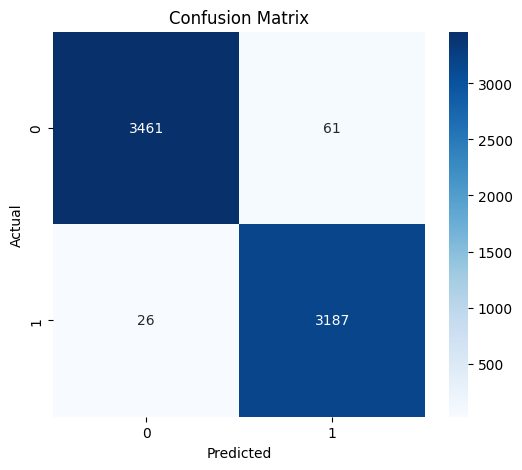

In [ ]:
cm = confusion_matrix(y_val, val_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
test_predictions = baseline_model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, test_predictions)
test_precision = precision_score(y_test, test_predictions)
test_recall = recall_score(y_test, test_predictions)
test_f1 = f1_score(y_test, test_predictions)
print("TEST RESULTS")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1-score:", test_f1)

TEST RESULTS
Accuracy: 0.9861915367483296
Precision: 0.9838659633881477
Recall: 0.9872353673723536
F1-score: 0.9855477855477855


In [ ]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ]
})

results

,Metric,Score
0,Accuracy,0.986192
1,Precision,0.983866
2,Recall,0.987235
3,F1-score,0.985548


In [ ]:
sample_texts = X_test.iloc[:5]

sample_predictions = baseline_model.predict(
    vectorizer.transform(sample_texts)
)
for i in range(5):

    print("TEXT:")
    print(sample_texts.iloc[i][:500])

    print("\nPREDICTION:", sample_predictions[i])

    print("REAL LABEL:", y_test.iloc[i])

    print("\n" + "="*80 + "\n")

TEXT:
MEET THE NASTY WOMEN Responsible For Promoting Hate And Intolerance On Nazi-Themed Trump Billboard [VIDEO] A menacing Donald Trump is gazing down on Phoenix s Grand Avenue.The president is flanked by mushroom clouds and swastikas configured like dollar signs. I think a lot of people are feeling this way and I m just trying to express what I think is on a lot of people s minds these days,  the billboard s artist, Karen Fiorito, said Friday in an interview from her California home. Something that 

PREDICTION: 0
REAL LABEL: 0


TEXT:
WOW! Watch Side By Side Comparison Of Hillary’s LIES Next To FBI Director’s Report On Email Scandal [VIDEO] This video is truly one of the best examples of how Hillary lies and manipulates low-information voters into believing she is innocent of any wrongdoing even when it is crystal clear she is guilty 

PREDICTION: 0
REAL LABEL: 0


TEXT:
 Top Republican Senator BLISTERS Trump For Demanding The DOJ Persecute Hillary Clinton It s official. Donald Trum

text preprocessing and train/validation/test splitting were completed.

TF-IDF vectorization was applied to convert text into numerical feature vectors.

A Logistic Regression baseline model was implemented and trained on the dataset.


The baseline model achieved strong performance on the fake news classification task.

The TF-IDF representation captured important textual patterns and allowed the Logistic Regression model to separate fake and real news effectively.


# **# DEEP LEARNING MODELS (RNN / LSTM / GRU)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from collections import Counter
import re

In [ ]:
X = df["full_text"]
y = df["label"]

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = text.split()
    return tokens

BUILD VOCABULARY

In [ ]:
counter = Counter()
for text in X_train:
    counter.update(tokenize(text))

In [ ]:
from collections import Counter
counter = Counter()
for text in X_train:
    counter.update(tokenize(text))
vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}
for word, count in counter.items():
    if count >= 2:
        vocab[word] = len(vocab)
print("Vocabulary size:", len(vocab))

Vocabulary size: 93801


In [ ]:
MAX_LEN = 300
def encode(text):
    tokens = tokenize(text)
    ids = []
    for token in tokens[:MAX_LEN]:
        ids.append(vocab.get(token, vocab["<UNK>"]))
    if len(ids) < MAX_LEN:
        ids += [vocab["<PAD>"]] * (MAX_LEN - len(ids))
    return ids
X_train_encoded = [encode(text) for text in X_train]
X_val_encoded = [encode(text) for text in X_val]
X_test_encoded = [encode(text) for text in X_test]

In [ ]:
X_train_tensor = torch.tensor(X_train_encoded, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_encoded, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_encoded, dtype=torch.long)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)
print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([31428, 300])
torch.Size([31428])


In [ ]:
class NewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
train_dataset = NewsDataset(
    X_train_tensor,
    y_train_tensor
)
val_dataset = NewsDataset(
    X_val_tensor,
    y_val_tensor
)
test_dataset = NewsDataset(
    X_test_tensor,
    y_test_tensor
)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32
)
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(device)

cpu


In [ ]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size,
            64,
            padding_idx=0
        )
        self.rnn = nn.RNN(
            input_size=64,
            hidden_size=128,
            batch_first=True
        )
        self.fc = nn.Linear(128, 1)
    def forward(self, x):
        x = self.embedding(x)
        output, hidden = self.rnn(x)
        out = self.fc(hidden[-1])
        return out.squeeze(1)

In [ ]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size,
            64,
            padding_idx=0
        )
        self.gru = nn.GRU(
            input_size=64,
            hidden_size=128,
            batch_first=True
        )
        self.fc = nn.Linear(128, 1)
    def forward(self, x):
        x = self.embedding(x)
        output, hidden = self.gru(x)
        out = self.fc(hidden[-1])
        return out.squeeze(1)

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=64,
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=128,
            batch_first=True
        )
        self.fc = nn.Linear(128, 1)
    def forward(self, x):
        x = self.embedding(x)
        output, (hidden, cell) = self.lstm(x)
        hidden = hidden[-1]
        out = self.fc(hidden)
        return out.squeeze(1)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=3):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
        val_losses.append(val_loss / len(val_loader))
        print(f"Epoch {epoch+1} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")
    return model, train_losses, val_losses

In [ ]:
rnn_model = RNNModel(len(vocab))
rnn_model, rnn_train_loss, rnn_val_loss = train_model(rnn_model, train_loader, val_loader)

Epoch 1 | Train: 0.6734 | Val: 0.6151
Epoch 2 | Train: 0.6322 | Val: 0.4374
Epoch 3 | Train: 0.5980 | Val: 0.6633


In [ ]:
gru_model = GRUModel(len(vocab))
gru_model, gru_train_loss, gru_val_loss = train_model(gru_model, train_loader, val_loader)

Epoch 1 | Train: 0.2855 | Val: 0.0092
Epoch 2 | Train: 0.0132 | Val: 0.0070
Epoch 3 | Train: 0.0066 | Val: 0.0059


In [ ]:
lstm_model = LSTMModel(len(vocab))
lstm_model, lstm_train_loss, lstm_val_loss = train_model(lstm_model, train_loader, val_loader)

Epoch 1 | Train: 0.6710 | Val: 0.6810
Epoch 2 | Train: 0.6546 | Val: 0.5869
Epoch 3 | Train: 0.4909 | Val: 0.2116


# LOSS PLOTS

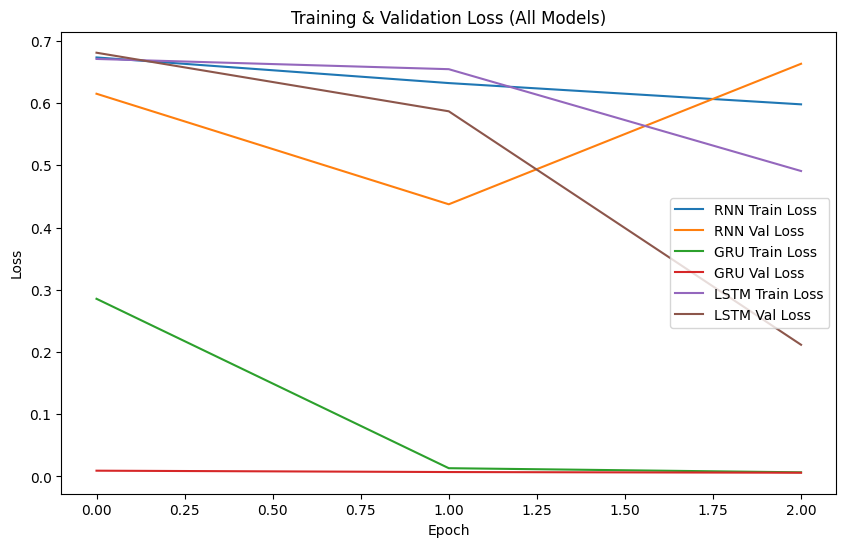

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(rnn_train_loss, label="RNN Train Loss")
plt.plot(rnn_val_loss, label="RNN Val Loss")

plt.plot(gru_train_loss, label="GRU Train Loss")
plt.plot(gru_val_loss, label="GRU Val Loss")

plt.plot(lstm_train_loss, label="LSTM Train Loss")
plt.plot(lstm_val_loss, label="LSTM Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (All Models)")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, test_loader):

    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            probs = torch.sigmoid(outputs)

            preds = (probs >= 0.5).int()

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(y_batch.numpy())

    acc = accuracy_score(true_labels, predictions)
    prec = precision_score(true_labels, predictions)
    rec = recall_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions)

    cm = confusion_matrix(true_labels, predictions)

    return acc, prec, rec, f1, cm, predictions, true_labels

In [ ]:
rnn_acc, rnn_prec, rnn_rec, rnn_f1, rnn_cm, rnn_preds, rnn_true = evaluate_model(rnn_model, test_loader)

print("RNN RESULTS")
print("Accuracy:",rnn_acc)
print("Precision:", rnn_prec)
print("Recall:", rnn_rec)
print("F1-score:", rnn_f1)

RNN RESULTS
Accuracy: 0.6163325909428359
Precision: 0.5816432657306292
Recall: 0.6964508094645081
F1-score: 0.6338906205724001


In [ ]:
gru_acc, gru_prec, gru_rec, gru_f1, gru_cm, gru_preds, gru_true = evaluate_model(gru_model, test_loader)

print("GRU RESULTS")
print("Accuracy:",gru_acc)
print("Precision:", gru_prec)
print("Recall:", gru_rec)
print("F1-score:", gru_f1)

GRU RESULTS
Accuracy: 0.9985152190051967
Precision: 0.9996878901373284
Recall: 0.9971980074719801
F1-score: 0.9984413965087282


In [ ]:
lstm_acc, lstm_prec, lstm_rec, lstm_f1, lstm_cm, lstm_preds, lstm_true = evaluate_model(lstm_model, test_loader)

print("LSTM RESULTS")
print("Accuracy:",lstm_acc)
print("Precision:", lstm_prec)
print("Recall:", lstm_rec)
print("F1-score:", lstm_f1)

LSTM RESULTS
Accuracy: 0.9221974758723088
Precision: 0.9409448818897638
Recall: 0.8929016189290162
F1-score: 0.91629392971246


CONFUSION MATRIX FOR ALL MODELS

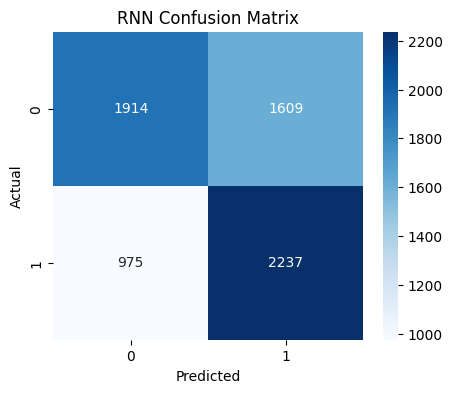

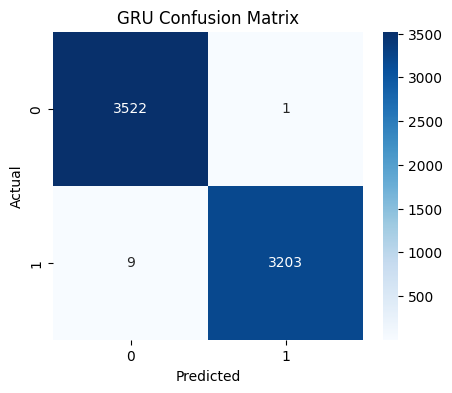

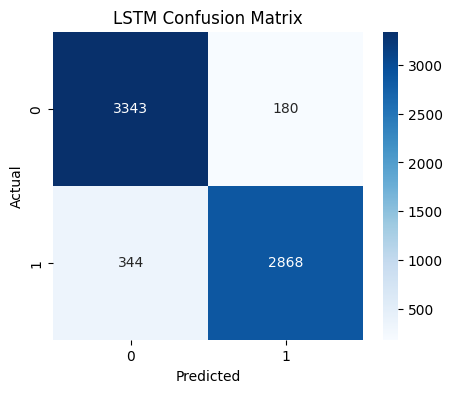

In [ ]:
def plot_cm(cm, title):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(rnn_cm, "RNN Confusion Matrix")
plot_cm(gru_cm, "GRU Confusion Matrix")
plot_cm(lstm_cm, "LSTM Confusion Matrix")

# FINAL COMPARISON TABLE

In [ ]:
import pandas as pd

comparison_results = pd.DataFrame({
    "Model": ["RNN", "GRU", "LSTM"],

    "Accuracy": [rnn_acc, gru_acc, lstm_acc],
    "Precision": [rnn_prec, gru_prec, lstm_prec],
    "Recall": [rnn_rec, gru_rec, lstm_rec],
    "F1-score": [rnn_f1, gru_f1, lstm_f1]
})

comparison_results

,Model,Accuracy,Precision,Recall,F1-score
0,RNN,0.616333,0.581643,0.696451,0.633891
1,GRU,0.998515,0.999688,0.997198,0.998441
2,LSTM,0.922197,0.940945,0.892902,0.916294


In [ ]:
best_model_name = comparison_results.sort_values("F1-score", ascending=False).iloc[0]["Model"]

print("Best model is:", best_model_name)

Best model is: GRU


# PREDICT FUNCTION

In [ ]:
loaded_model = gru_model  # BEST MODEL

def predict_news(text):

    encoded = encode(text)

    tensor = torch.tensor([encoded], dtype=torch.long).to(device)

    loaded_model.eval()

    with torch.no_grad():
        output = loaded_model(tensor)
        prob = torch.sigmoid(output).item()

    label = "REAL NEWS" if prob >= 0.5 else "FAKE NEWS"

    return label, prob

In [ ]:
sample_text = """
The government announced new economic reforms
to improve the financial system of the country.
"""

label, prob = predict_news(sample_text)

print("Prediction:", label)
print("Probability:", prob)

Prediction: FAKE NEWS
Probability: 0.002631321083754301


# ERROR ANALYSIS

In [ ]:
print("\n" + "="*60)
print("DETAILED ERROR ANALYSIS")
print("="*60)

false_positives = 0
false_negatives = 0

for err in incorrect_predictions:
    if err['true'] == 1 and err['predicted'] == 0:
        false_negatives += 1
    elif err['true'] == 0 and err['predicted'] == 1:
        false_positives += 1

print(f"False Positives (FAKE incorrectly marked as REAL): {false_positives}")
print(f"False Negatives (REAL incorrectly marked as FAKE): {false_negatives}")

short_errors = 0
medium_errors = 0
long_errors = 0

for err in incorrect_predictions:
    text_len = len(err['text'])
    if text_len < 200:
        short_errors += 1
    elif text_len < 600:
        medium_errors += 1
    else:
        long_errors += 1

print(f"\nErrors by text length:")
print(f"  Short (<200 chars): {short_errors}")
print(f"  Medium (200-600): {medium_errors}")
print(f"  Long (>600): {long_errors}")

print("\n" + "="*60)
print("EXAMPLE MISTAKES (with explanation)")
print("="*60)

for i, err in enumerate(incorrect_predictions[:3]):
    print(f"\n--- Mistake #{i+1} ---")
    print(f"TRUE label: {'REAL' if err['true']==1 else 'FAKE'}")
    print(f"PREDICTED: {'REAL' if err['predicted']==1 else 'FAKE'}")
    print(f"Confidence: {err['probability']:.2%}")
    print(f"Text excerpt: {err['text']}...")
    print(f"Possible reason: {'Text is very short' if len(err['text'])<200 else 'Ambiguous content'}")


DETAILED ERROR ANALYSIS
False Positives (FAKE incorrectly marked as REAL): 1
False Negatives (REAL incorrectly marked as FAKE): 9

Errors by text length:
  Short (<200 chars): 0
  Medium (200-600): 10
  Long (>600): 0

EXAMPLE MISTAKES (with explanation)

--- Mistake #1 ---
TRUE label: REAL
PREDICTED: FAKE
Confidence: 0.99%
Text excerpt: China to expand corruption supervision pilot scheme nationwide: Xinhua BEIJING - China will expand a pilot project for anti-graft supervision reforms nationwide next year that will consolidate existing corruption agencies, state-run news agency Xinhua reported, as President Xi Jinping expands his si...
Possible reason: Ambiguous content

--- Mistake #2 ---
TRUE label: REAL
PREDICTED: FAKE
Confidence: 3.39%
Text excerpt: Clinton says Trump is most divisive candidate 'in our lifetimes' In a speech weighted with America’s complicated racial history, Democrat Hillary Clinton laced into Republican presidential rival Donald Trump on Wednesday, accusing him 

# **STREAMLIT APP**

In [ ]:
import pickle, torch
with open("vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)
torch.save(rnn_model.state_dict(), "rnn_model.pt")
torch.save(gru_model.state_dict(), "gru_model.pt")
torch.save(lstm_model.state_dict(), "lstm_model.pt")
from google.colab import files
files.download("vocab.pkl")
files.download("rnn_model.pt")
files.download("gru_model.pt")
files.download("lstm_model.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 42.9 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# PAGE CONFIG
st.set_page_config(page_title="Fake News Detector", layout="wide")

st.title("📰 Fake News Detection System (RNN / LSTM / GRU)")

st.write("Select model and input text to classify news as FAKE or REAL.")

# LOAD MODELS
models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# TOKENIZER
def tokenize(text):
    return text.lower().split()

MAX_LEN = 300

def encode(text, vocab):
    tokens = tokenize(text)

    ids = [vocab.get(t, vocab["<UNK>"]) for t in tokens[:MAX_LEN]]

    if len(ids) < MAX_LEN:
        ids += [vocab["<PAD>"]] * (MAX_LEN - len(ids))

    return ids

# PREDICT FUNCTION
def predict(model, text, vocab):

    model.eval()

    encoded = encode(text, vocab)

    tensor = torch.tensor([encoded], dtype=torch.long).to(device)

    with torch.no_grad():
        output = model(tensor)
        prob = torch.sigmoid(output).item()

    label = "REAL NEWS" if prob >= 0.5 else "FAKE NEWS"

    return label, prob

# UI INPUT

col1, col2 = st.columns(2)

with col1:
    model_name = st.selectbox("Choose Model", ["RNN", "LSTM", "GRU"])

with col2:
    text_input = st.text_area("Enter News Text")

# PREDICTION
if st.button("Predict"):

    if text_input.strip() == "":
        st.warning("Please enter text.")
    else:
        model = models[model_name]

        label, prob = predict(model, text_input, vocab)

        st.subheader("Prediction Result")

        if label == "REAL NEWS":
            st.success(f"Prediction: {label}")
        else:
            st.error(f"Prediction: {label}")

        st.write(f"Confidence Score: {prob:.4f}")

2026-05-22 00:26:23.581 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:23.582 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:23.698 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-22 00:26:23.699 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:23.700 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:23.701 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:23.702 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [ ]:
st.subheader("Confusion Matrix Viewer")

model_cm = st.selectbox("Select model for CM", ["RNN", "LSTM", "GRU"])

if st.button("Show Confusion Matrix"):

    cm = {
        "RNN": rnn_cm,
        "LSTM": lstm_cm,
        "GRU": gru_cm
    }[model_cm]

    fig, ax = plt.subplots()

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)

    ax.set_title(f"{model_cm} Confusion Matrix")

    st.pyplot(fig)

2026-05-22 00:26:40.645 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:40.647 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:40.649 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:40.651 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:40.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:40.654 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:40.654 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:40.655 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

2026-05-22 00:26:50.348 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:50.350 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:50.350 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:50.402 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:50.403 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:50.405 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:50.439 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-22 00:26:50.582 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

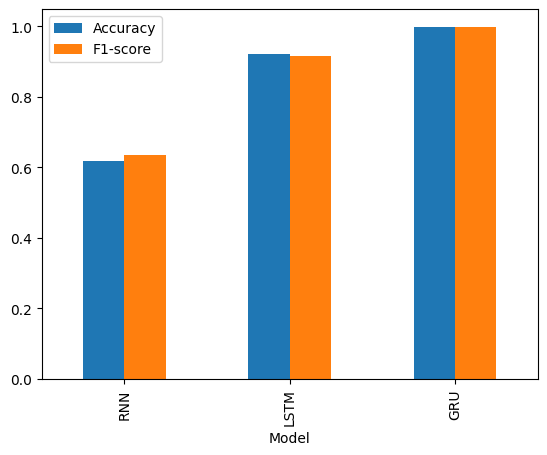

In [ ]:
st.subheader("Model Performance Comparison")

results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Accuracy": [rnn_acc, lstm_acc, gru_acc],
    "Precision": [rnn_prec, lstm_prec, gru_prec],
    "Recall": [rnn_rec, lstm_rec, gru_rec],
    "F1-score": [rnn_f1, lstm_f1, gru_f1]
})

st.dataframe(results)

fig, ax = plt.subplots()
results.set_index("Model")[["Accuracy", "F1-score"]].plot(kind="bar", ax=ax)
st.pyplot(fig)